In [ ]:
import os
import random
import numpy as np
from PIL import Image, UnidentifiedImageError
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.utils import  img_to_array, load_img, array_to_img
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dropout, Flatten, Dense
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix

In [3]:
dataset_path = r"C:\Users\souis\Downloads\archive\DATASET"  # ou 'dataset/train'

# Dictionnaire des noms de classes
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry','neutral']

In [4]:
img_w, img_h = 128, 128
X = []
y = []

# Chargement des images pour l'ensemble d'entraînement
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        try:
            img = Image.open(os.path.join(class_dir, img_name)).convert('RGB')
            img = img.resize((img_w, img_h))
            X.append(np.asarray(img))
            y.append(label)
        except UnidentifiedImageError:
            pass

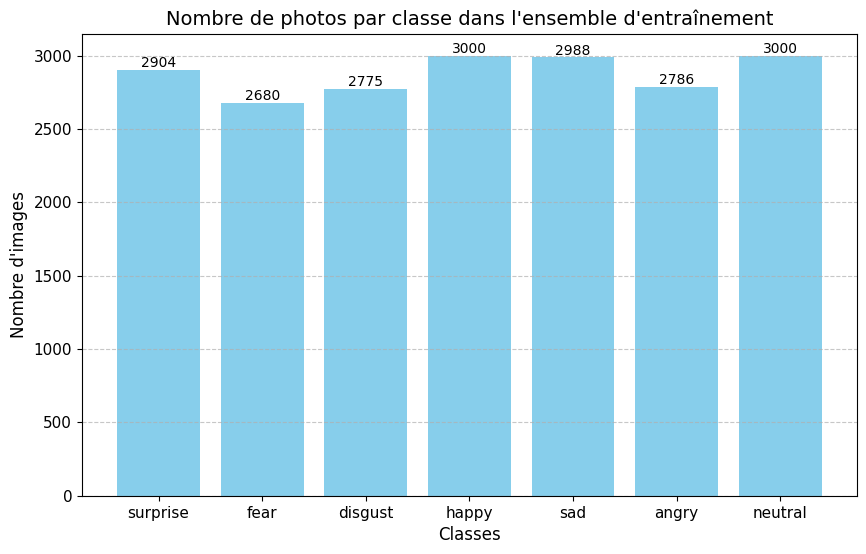

In [5]:
# Compter le nombre d'images par classe
counts = [0] * len(classes)
for label in y:
    counts[label] += 1

# Créer l'histogramme
plt.figure(figsize=(10, 6))
bars = plt.bar(classes, counts, color='skyblue')

# Ajouter les valeurs exactes au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             '%d' % int(height),
             ha='center', va='bottom')

# Ajouter des titres et labels
plt.title('Nombre de photos par classe dans l\'ensemble d\'entraînement', fontsize=14)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Nombre d\'images', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher une grille pour une meilleure lisibilité
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [6]:
X = np.array(X)  # Conversion en array
x = X.astype('float32')  # Normalisation
x /= 255

# Encodage des labels en one-hot
num_classes = len(classes)
labels = keras.utils.to_categorical(y, num_classes)

In [7]:
# Étape 1 : on garde 30% pour val + test
x_temp, x_train, y_temp, y_train = train_test_split(
    x, labels, test_size=0.7, random_state=5, stratify=labels)

# Étape 2 : on divise les 30% restants en 15% val et 15% test
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=5, stratify=y_temp)

In [8]:
print('Number of train: {}'.format(len(x_train)))
print('Number of validation: {}'.format(len(x_val)))
print('Number of test: {}'.format(len(x_test)))

Number of train: 14094
Number of validation: 3019
Number of test: 3020


In [9]:
# Augmentation des données
datagen = ImageDataGenerator(
    featurewise_center=False,
    samplewise_center=False,
    featurewise_std_normalization=False,
    samplewise_std_normalization=False,
    zca_whitening=False,
    rotation_range=20.,
    width_shift_range=0.5,
    height_shift_range=0.5,
    shear_range=30.,
    zoom_range=0.,
    channel_shift_range=0.,
    fill_mode='nearest',
    cval=0.,
    horizontal_flip=0.2,
    vertical_flip=0.2,
    rescale=None
)

datagen.fit(x_train)

In [10]:
# Chargement du modèle pré-entraîné InceptionV3
base_model = tf.keras.applications.InceptionV3(input_shape=(128, 128, 3), include_top=False, weights="imagenet")


In [11]:
# Création du modèle
model = Sequential()
model.add(base_model)
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inception_v3 (Functional)   (None, 2, 2, 2048)        21802784  
                                                                 
 dropout (Dropout)           (None, 2, 2, 2048)        0         
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 128)               1048704   
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 7)                 903       
                                                                 
Total params: 22,868,903
Trainable params: 22,834,471
No

In [12]:
# Définition des métriques
METRICS = [
    tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
]

In [13]:
# Définition des callbacks

reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_delta=0.0001, verbose=1) 
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)  
checkpoint = ModelCheckpoint(filepath='best_InceptionV3Model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

In [14]:
# Compilation du modèle
model.compile(
    optimizer='Adam',
    loss=tf.keras.losses.CategoricalCrossentropy(reduction='sum_over_batch_size'),
    metrics=METRICS
)

In [16]:
# Entraînement du modèle avec les callbacks
history = model.fit(
    x_train, 
    y_train, 
    validation_data=(x_val, y_val), 
    epochs=30,  # Nombre d'époques ajusté
    batch_size=32,  # Taille du batch
    verbose=1,
    callbacks=[reduce_lr, early_stop, checkpoint]  # Ajout des callbacks
)

Epoch 1/30
441/441 [==============================] - ETA: 0s - loss: 0.8829 - accuracy: 0.6921 - precision: 0.8438 - recall: 0.5705 - auc: 0.9346
Epoch 1: val_accuracy improved from -inf to 0.68235, saving model to best_InceptionV3Model.keras
441/441 [==============================] - 520s 1s/step - loss: 0.8829 - accuracy: 0.6921 - precision: 0.8438 - recall: 0.5705 - auc: 0.9346 - val_loss: 3.0010 - val_accuracy: 0.6823 - val_precision: 0.7356 - val_recall: 0.6148 - val_auc: 0.8889 - lr: 0.0010
Epoch 2/30
441/441 [==============================] - ETA: 0s - loss: 0.6940 - accuracy: 0.7717 - precision: 0.8526 - recall: 0.6835 - auc: 0.9588
Epoch 2: val_accuracy improved from 0.68235 to 0.75555, saving model to best_InceptionV3Model.keras
441/441 [==============================] - 536s 1s/step - loss: 0.6940 - accuracy: 0.7717 - precision: 0.8526 - recall: 0.6835 - auc: 0.9588 - val_loss: 0.9634 - val_accuracy: 0.7555 - val_precision: 0.8272 - val_recall: 0.6883 - val_auc: 0.9489 - lr

95/95 [==============================] - 21s 193ms/step


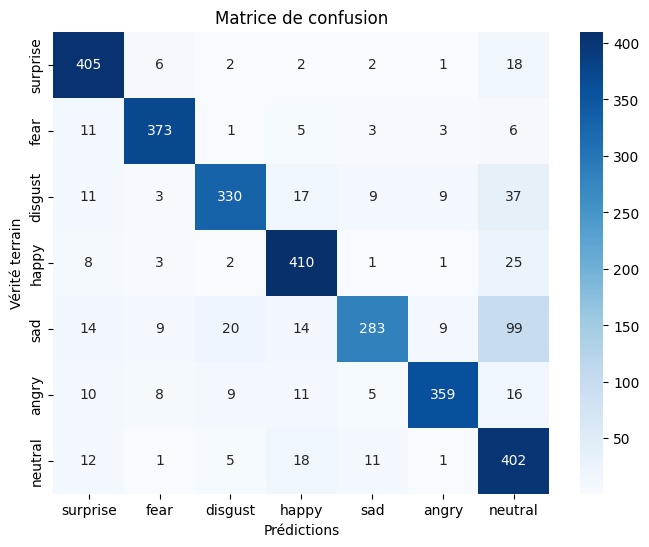

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
# Prédictions sur les données de test
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred_classes)

# Affichage
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Prédictions')
plt.ylabel('Vérité terrain')
plt.title('Matrice de confusion')
plt.show()

95/95 [==============================] - 19s 198ms/step


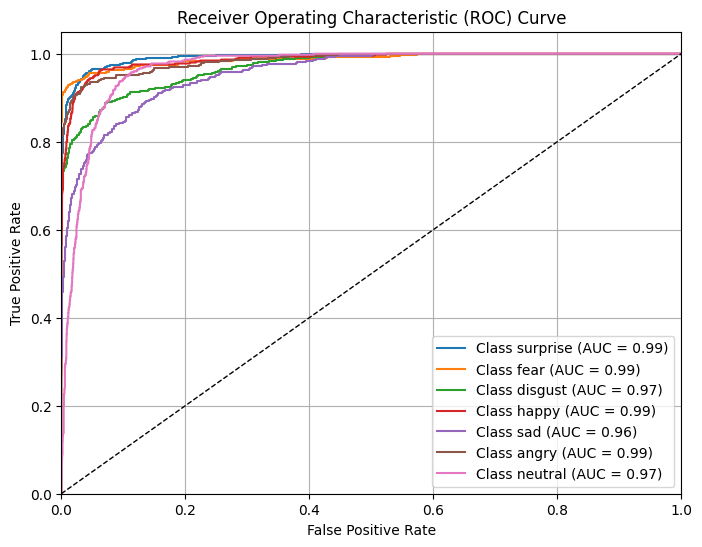

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# Liste des classes
classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']
n_classes = len(classes)

# Prédictions sur x_test
y_score = model.predict(x_test)
y_true = np.argmax(y_test, axis=1)

# Binarisation des labels vrais (au cas où ce n'est pas déjà fait)
y_test_bin = label_binarize(y_true, classes=np.arange(n_classes))

# Courbes ROC par classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracé
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
